# TFT Set 16 — Exploratory Data Analysis

Analysis of 1000 high-elo (Challenger/Grandmaster/Master) TFT matches from the NA server.

**Data sources:** `matches.csv`, `participants.csv`, `units.csv`, `traits.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load data
matches = pd.read_csv('data/processed/matches.csv')
participants = pd.read_csv('data/processed/participants.csv')
units = pd.read_csv('data/processed/units.csv')
traits = pd.read_csv('data/processed/traits.csv')

# Strip TFT16_ prefix for readability
units['champion'] = units['character_id'].str.replace('TFT16_', '', regex=False)
traits['trait'] = traits['name'].str.replace('TFT16_', '', regex=False)

n_matches = matches.shape[0]
n_participants = participants.shape[0]
print(f'Matches: {n_matches} | Participant records: {n_participants}')
print(f'Unique champions: {units["champion"].nunique()} | Unique traits: {traits["trait"].nunique()}')

Matches: 1000 | Participant records: 7986
Unique champions: 141 | Unique traits: 76


## 1. Placement Distribution

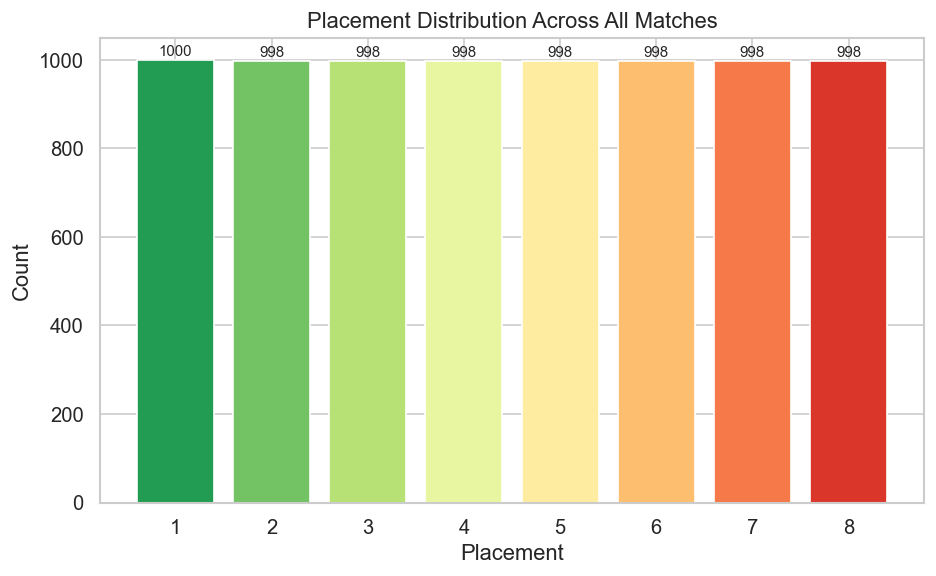

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = participants['placement'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn_r', n_colors=8)
ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Placement')
ax.set_ylabel('Count')
ax.set_title('Placement Distribution Across All Matches')
ax.set_xticks(range(1, 9))
for i, v in enumerate(counts.values):
    ax.text(counts.index[i], v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Key Finding:** The placement distribution is roughly uniform (≈1/8 each), as expected — every match produces exactly one player at each rank. Minor deviations come from some matches having fewer than 8 recorded participants.

## 2. Top 20 Champions by Pick Rate (with Average Placement)

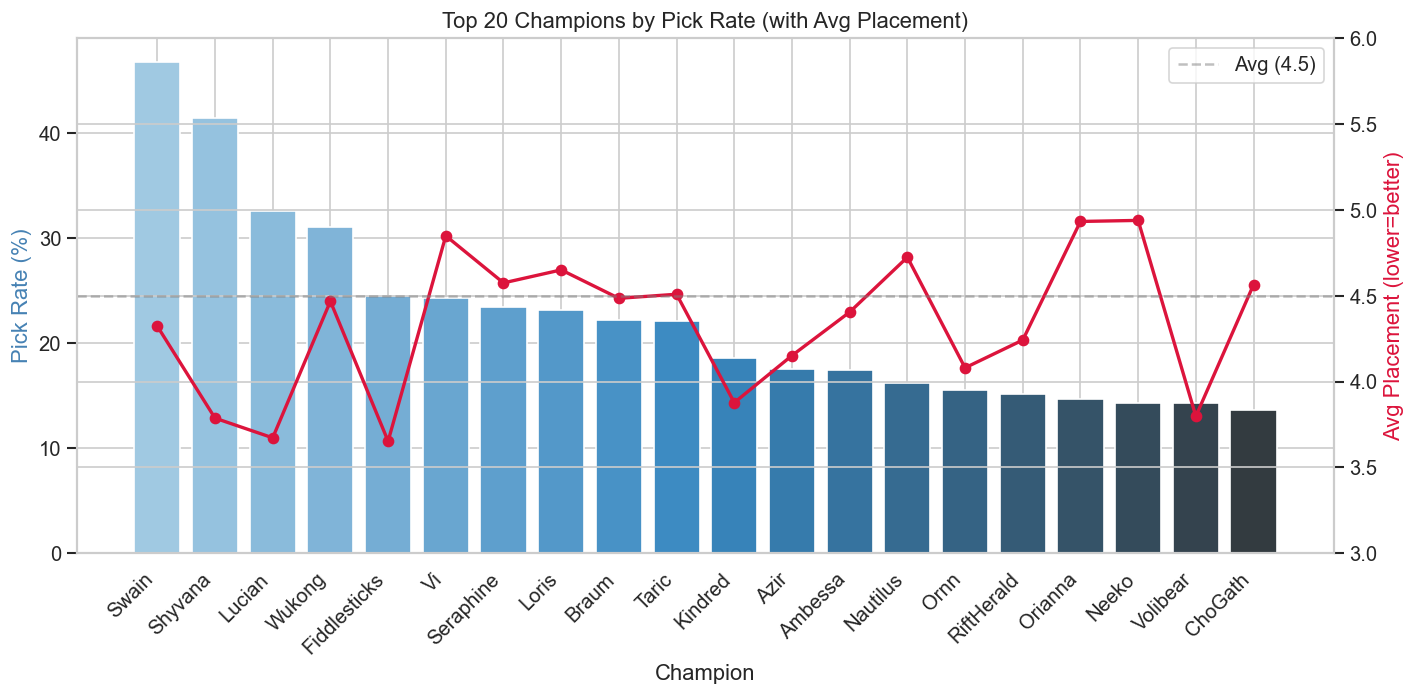

In [3]:
# Merge placement onto units
units_p = units.merge(participants[['match_id', 'puuid', 'placement']], on=['match_id', 'puuid'])

# Pick rate = fraction of participant-boards containing this champion
champ_stats = units_p.groupby('champion').agg(
    pick_count=('placement', 'size'),
    avg_placement=('placement', 'mean')
).reset_index()
champ_stats['pick_rate'] = champ_stats['pick_count'] / n_participants * 100
top20 = champ_stats.nlargest(20, 'pick_rate')

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(top20))
bars = ax1.bar(x, top20['pick_rate'], color=sns.color_palette('Blues_d', 20), edgecolor='white')
ax1.set_ylabel('Pick Rate (%)', color='steelblue')
ax1.set_xlabel('Champion')
ax1.set_title('Top 20 Champions by Pick Rate (with Avg Placement)')
ax1.set_xticks(x)
ax1.set_xticklabels(top20['champion'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, top20['avg_placement'], 'o-', color='crimson', linewidth=2, markersize=6)
ax2.set_ylabel('Avg Placement (lower=better)', color='crimson')
ax2.set_ylim(3, 6)
ax2.axhline(4.5, color='gray', linestyle='--', alpha=0.5, label='Avg (4.5)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Key Finding:** High pick rate doesn't always correlate with good placements. Some popular champions are just common early/mid-game units (cheap cost), while expensive carries with lower pick rates tend to have better average placement. Champions with both high pick rate AND below-average placement are the meta-defining units.

## 3. Top 15 Traits by Activation Frequency (Stacked by Style Level)

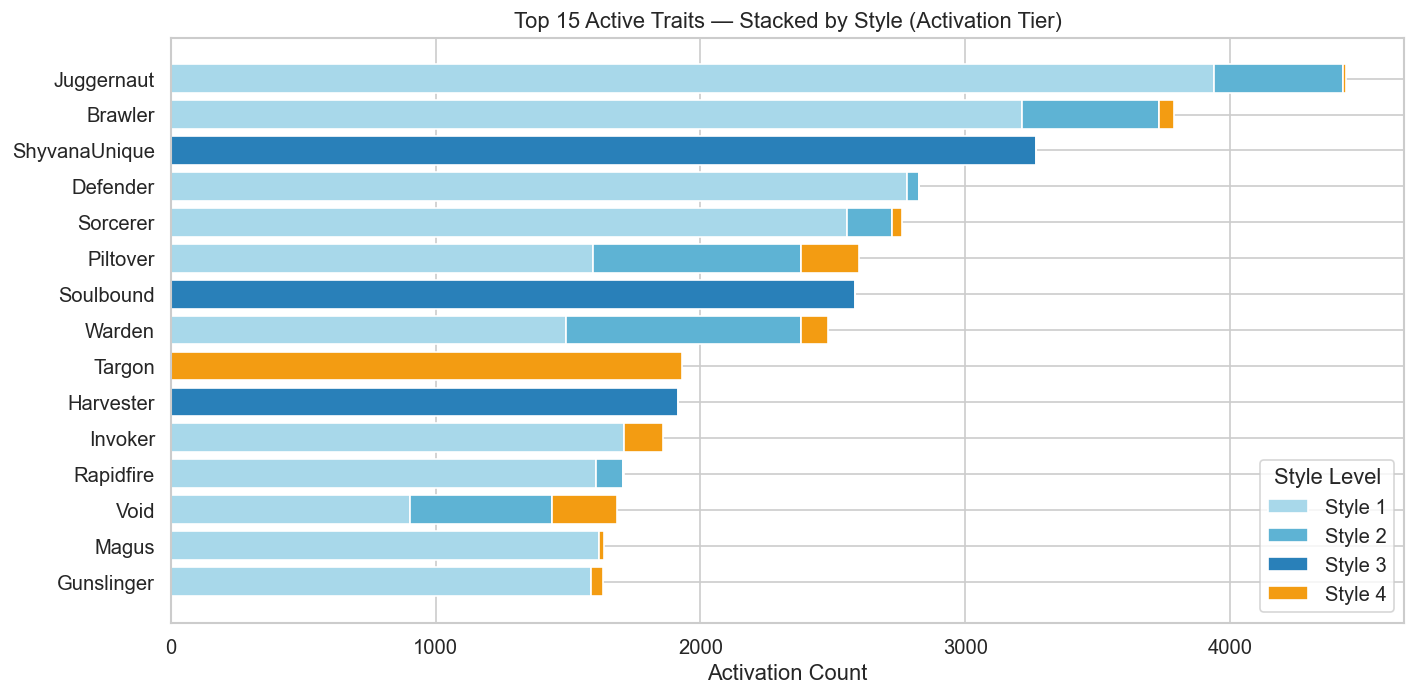

In [4]:
# Only count activated traits (style > 0)
active_traits = traits[traits['style'] > 0].copy()

# Top 15 traits by total activation count
top_traits = active_traits['trait'].value_counts().head(15).index.tolist()
at_top = active_traits[active_traits['trait'].isin(top_traits)]

# Pivot: trait x style level
pivot = at_top.groupby(['trait', 'style']).size().unstack(fill_value=0)
pivot = pivot.loc[top_traits]  # keep order

style_colors = {1: '#a8d8ea', 2: '#5eb3d4', 3: '#2980b9', 4: '#f39c12'}
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pivot))
for style_level in sorted(pivot.columns):
    vals = pivot[style_level].values
    color = style_colors.get(style_level, '#999999')
    ax.barh(pivot.index, vals, left=bottom, label=f'Style {style_level}', color=color, edgecolor='white')
    bottom += vals

ax.set_xlabel('Activation Count')
ax.set_title('Top 15 Active Traits — Stacked by Style (Activation Tier)')
ax.legend(title='Style Level')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Key Finding:** The most frequently activated traits define the meta. Traits that frequently reach Style 3-4 (gold/prismatic tier) are likely core to the strongest compositions. Traits that rarely go beyond Style 1 are usually "splash" traits activated as a side benefit.

## 4. Champion Cost (Rarity) vs Average Placement

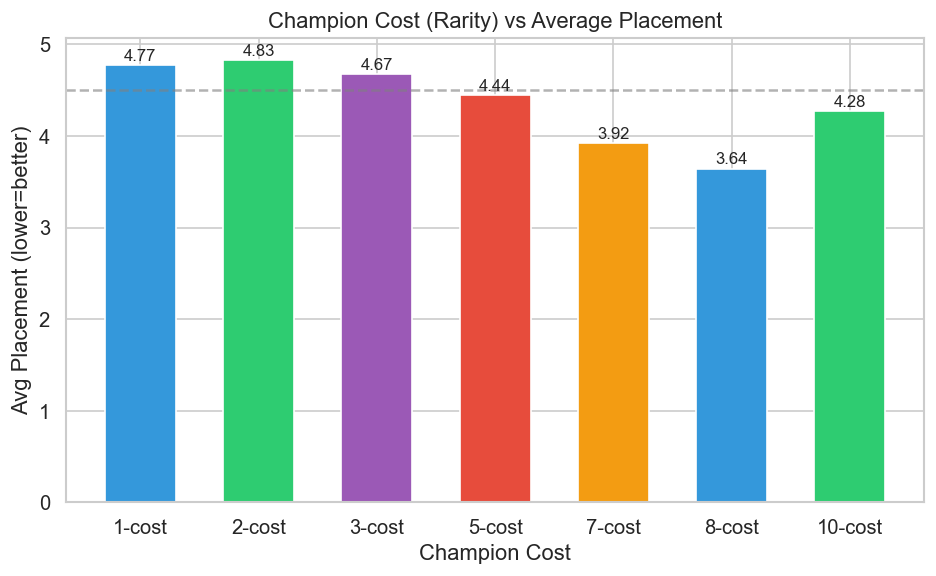

In [5]:
cost_stats = units_p.groupby('rarity').agg(
    avg_placement=('placement', 'mean'),
    count=('placement', 'size')
).reset_index()
cost_stats['rarity_label'] = (cost_stats['rarity'] + 1).astype(str) + '-cost'

fig, ax1 = plt.subplots(figsize=(8, 5))
palette = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
bars = ax1.bar(cost_stats['rarity_label'], cost_stats['avg_placement'],
               color=palette[:len(cost_stats)], edgecolor='white', width=0.6)
ax1.axhline(4.5, color='gray', linestyle='--', alpha=0.6)
ax1.set_ylabel('Avg Placement (lower=better)')
ax1.set_xlabel('Champion Cost')
ax1.set_title('Champion Cost (Rarity) vs Average Placement')

for bar, val in zip(bars, cost_stats['avg_placement']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Key Finding:** Higher-cost champions (4-cost, 5-cost) correlate with better (lower) average placements. This makes sense — players who survive long enough to find and upgrade expensive units tend to place higher. The relationship shows TFT's economic curve: investing in expensive carries is rewarded.

## 5. Top 20 Items & Which Champions Use Them

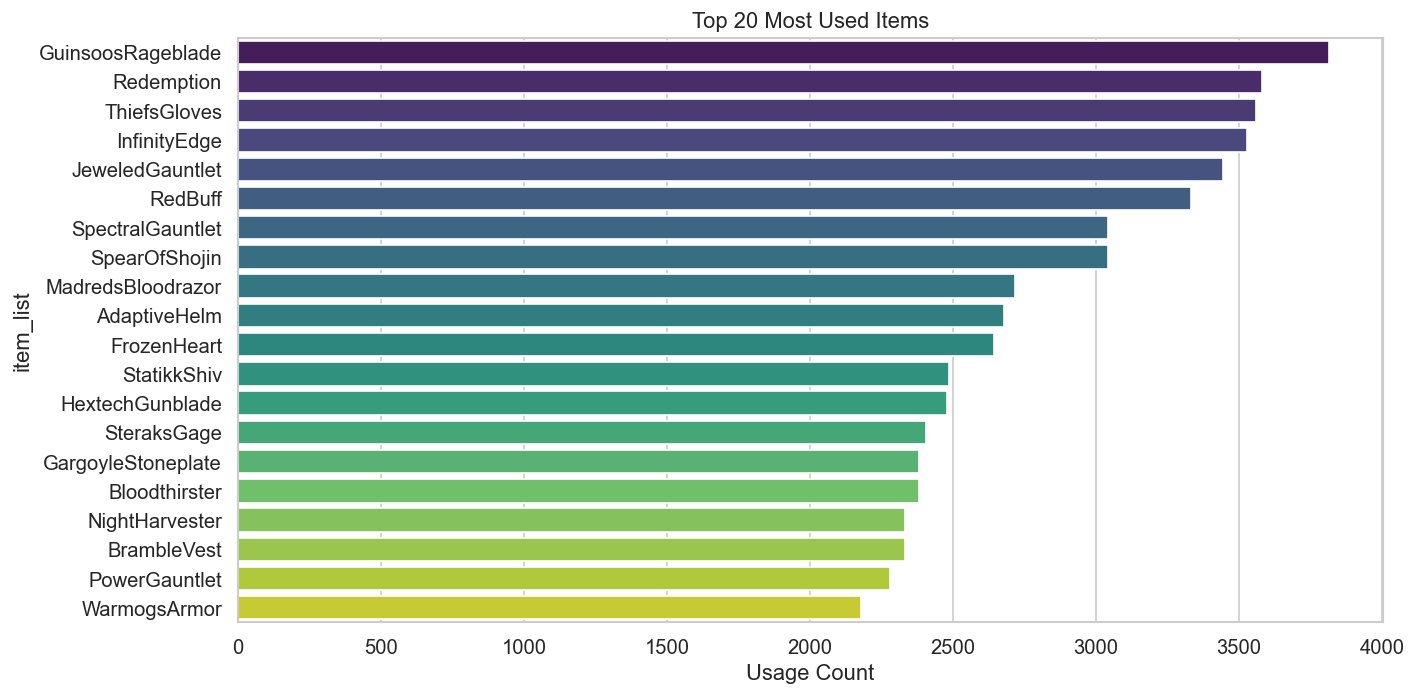

In [6]:
# Parse items column
def parse_items(item_str):
    try:
        items = json.loads(item_str.replace("'", '"'))
        return [i.replace('TFT_Item_', '').replace('TFT16_Item_', '') for i in items]
    except:
        return []

units['item_list'] = units['items'].apply(parse_items)
item_rows = units.explode('item_list').dropna(subset=['item_list'])
item_rows = item_rows[item_rows['item_list'] != '']

# Top 20 items
top_items = item_rows['item_list'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis', ax=ax)
ax.set_xlabel('Usage Count')
ax.set_title('Top 20 Most Used Items')
plt.tight_layout()
plt.show()

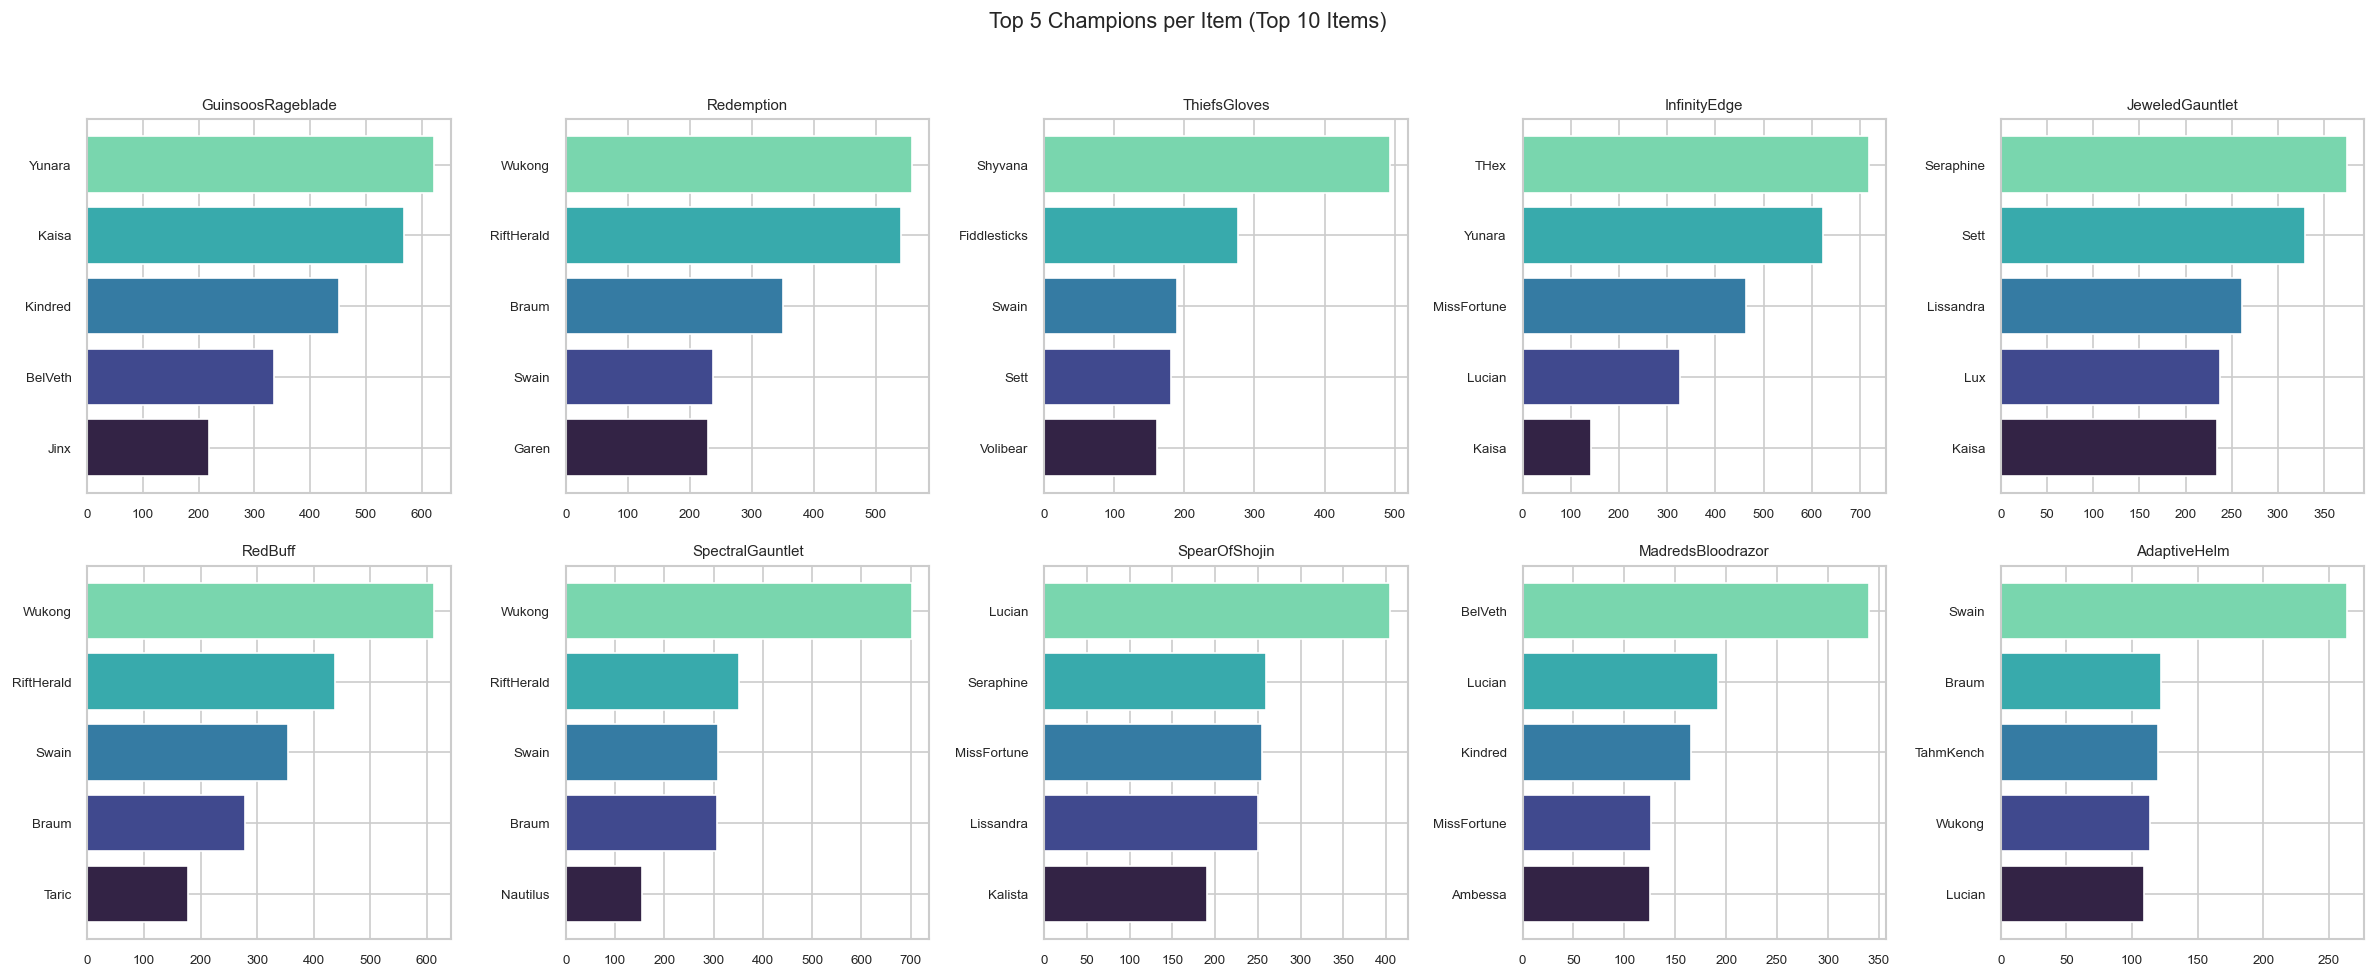

In [7]:
# Item-Champion affinity: for top 10 items, show top 5 champions
top10_items = top_items.head(10).index.tolist()
item_champ = item_rows[item_rows['item_list'].isin(top10_items)]

affinity = item_champ.groupby(['item_list', 'champion']).size().reset_index(name='count')
affinity_top = affinity.sort_values(['item_list', 'count'], ascending=[True, False])
affinity_top = affinity_top.groupby('item_list').head(5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for idx, item_name in enumerate(top10_items):
    ax = axes[idx // 5][idx % 5]
    subset = affinity_top[affinity_top['item_list'] == item_name].sort_values('count', ascending=True)
    ax.barh(subset['champion'], subset['count'], color=sns.color_palette('mako', 5))
    ax.set_title(item_name, fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Top 5 Champions per Item (Top 10 Items)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Key Finding:** Defensive items (Bramble Vest, Dragon's Claw, etc.) tend to be spread across many champions (frontline tanks), while offensive items (Infinity Edge, etc.) cluster on specific carry champions. This reveals which champions are the primary "item holders" in the meta.

## 6. Champion Co-occurrence Matrix (Top 30)

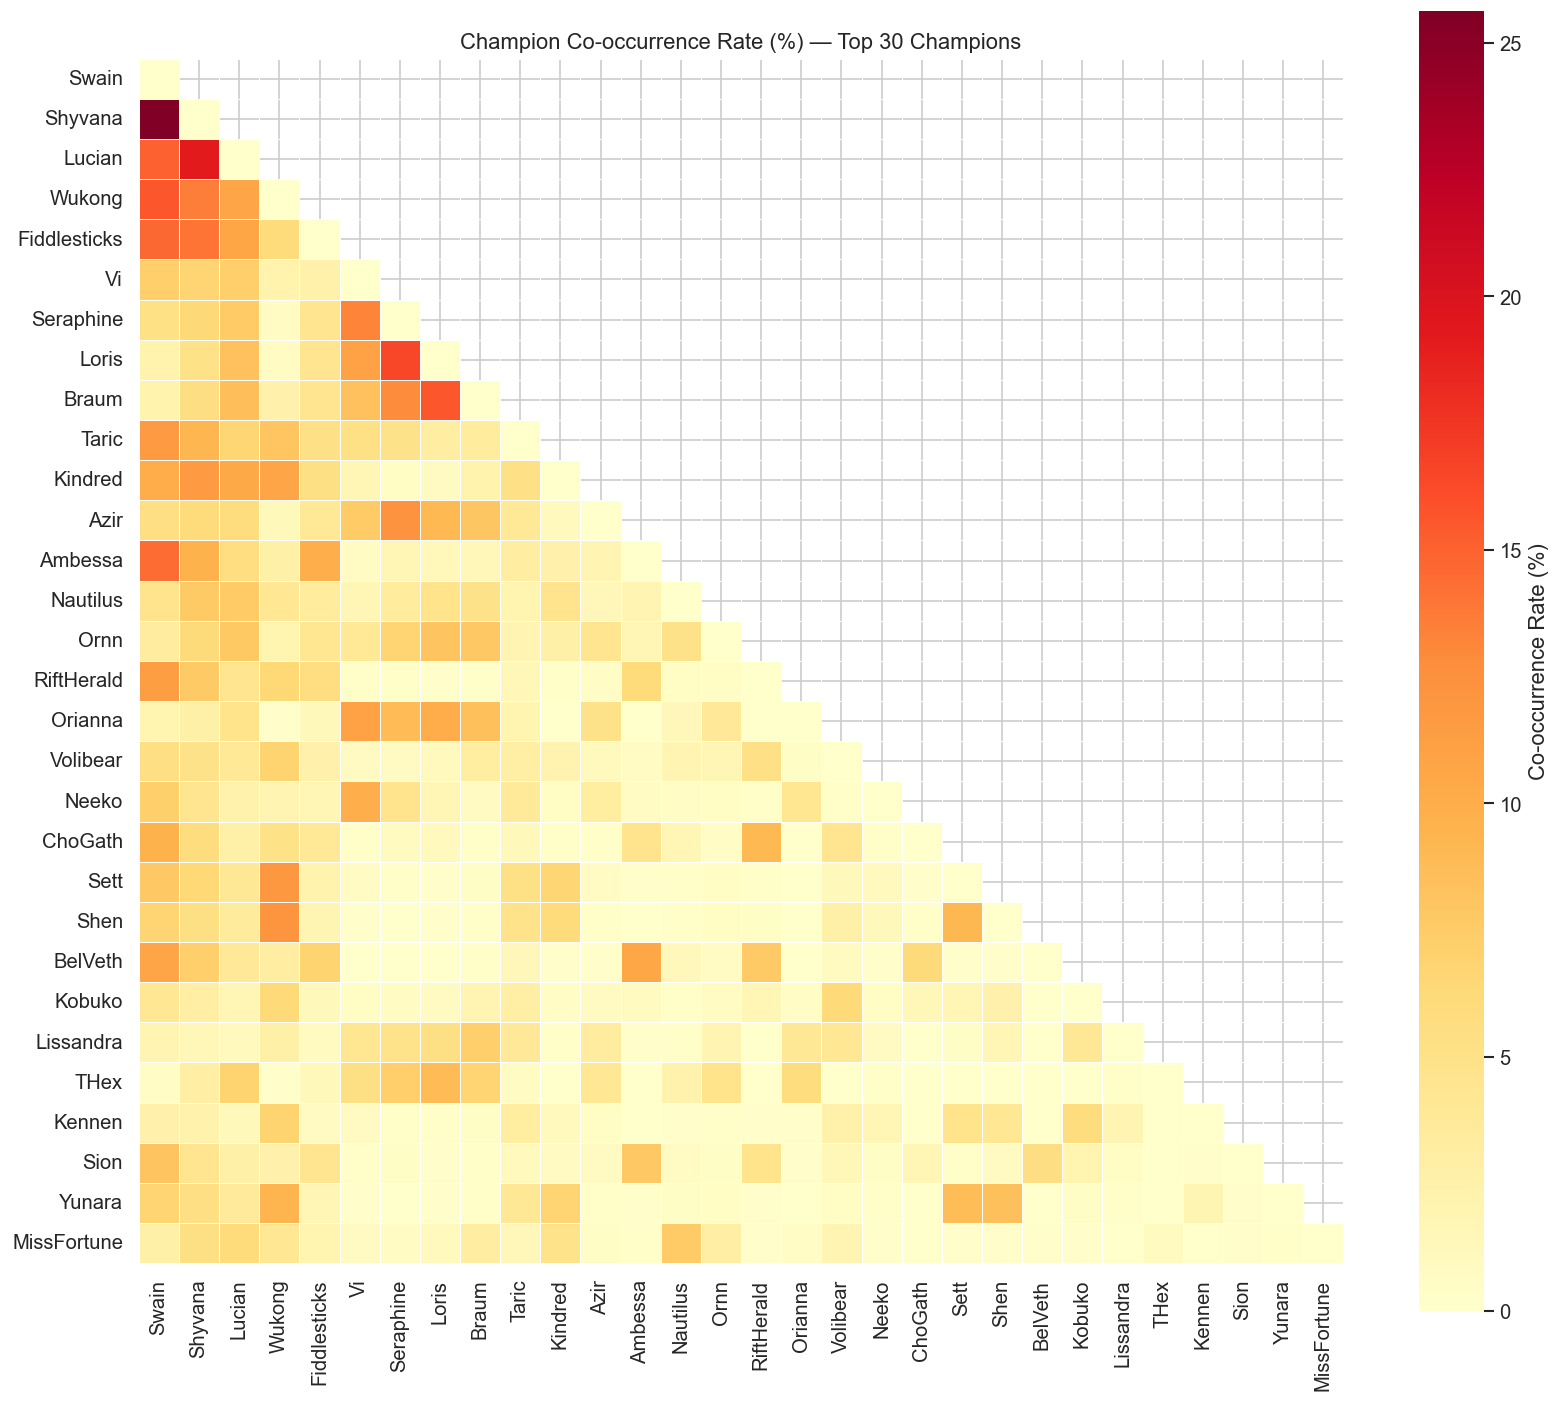

In [8]:
# Build board-level champion sets
boards = units.groupby(['match_id', 'puuid'])['champion'].apply(set).reset_index()

# Top 30 champions by pick count
top30 = units['champion'].value_counts().head(30).index.tolist()

# Co-occurrence matrix
cooc = pd.DataFrame(0, index=top30, columns=top30)
for _, row in boards.iterrows():
    champs_in_board = [c for c in row['champion'] if c in top30]
    for i, c1 in enumerate(champs_in_board):
        for c2 in champs_in_board[i+1:]:
            cooc.loc[c1, c2] += 1
            cooc.loc[c2, c1] += 1

# Normalize by total boards
cooc_norm = cooc / len(boards) * 100

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(cooc_norm, dtype=bool), k=1)
sns.heatmap(cooc_norm, mask=mask, cmap='YlOrRd', ax=ax,
            square=True, linewidths=0.3, cbar_kws={'label': 'Co-occurrence Rate (%)'},
            fmt='.1f')
ax.set_title('Champion Co-occurrence Rate (%) — Top 30 Champions')
plt.tight_layout()
plt.show()

**Key Finding:** Bright clusters in the heatmap reveal champion pairs that are frequently played together — these form the backbone of meta compositions. Diagonal blocks of high co-occurrence indicate synergy groups (likely sharing traits).

## 7. Correlation Heatmap: Level, Last Round, Gold Left vs Placement

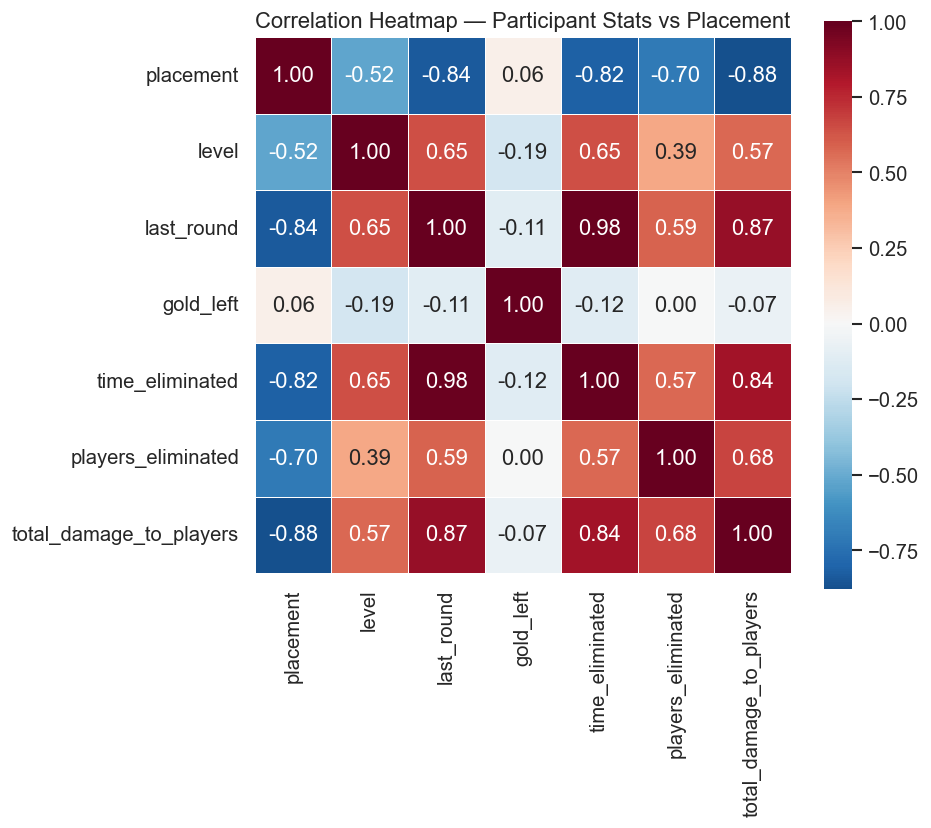

In [9]:
corr_cols = ['placement', 'level', 'last_round', 'gold_left', 'time_eliminated',
             'players_eliminated', 'total_damage_to_players']
corr_matrix = participants[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Participant Stats vs Placement')
plt.tight_layout()
plt.show()

**Key Finding:** `last_round` and `time_eliminated` have the strongest negative correlation with placement (lower placement = better). `level` also correlates — higher-level players tend to place better. `gold_left` has a weaker relationship, suggesting that spending gold wisely matters more than hoarding it.

## 8. Composition Clustering (KMeans + Hierarchical)

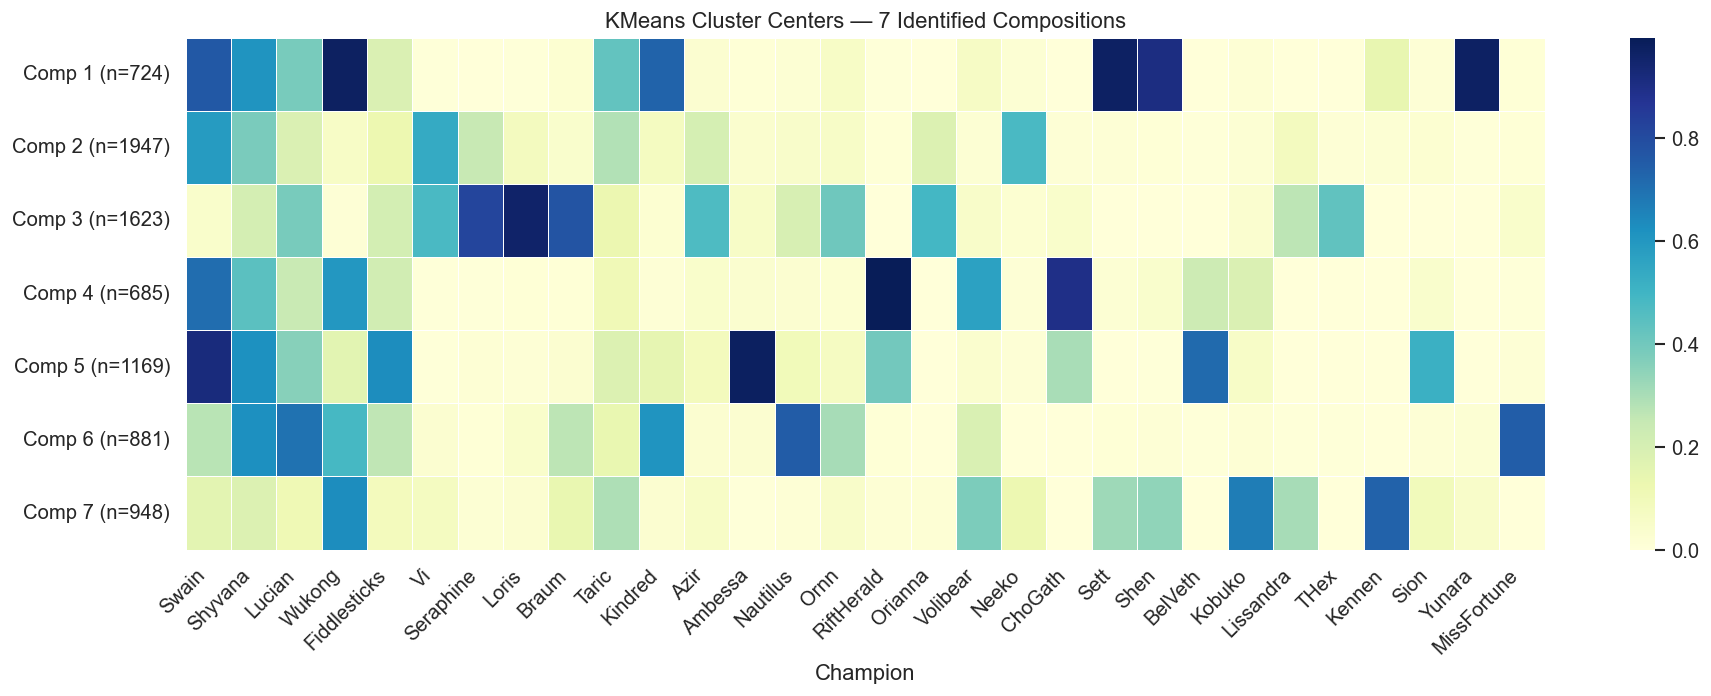

In [10]:
# Build a binary feature matrix: each row = one board, columns = top 30 champions
board_features = pd.DataFrame(0, index=boards.index, columns=top30)
for idx, row in boards.iterrows():
    for champ in row['champion']:
        if champ in top30:
            board_features.loc[idx, champ] = 1

X = board_features.values

# KMeans with 7 clusters
n_clusters = 7
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
boards['cluster'] = km.fit_predict(X)

# Show cluster centers — which champions define each comp
centers = pd.DataFrame(km.cluster_centers_, columns=top30)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(centers, cmap='YlGnBu', ax=ax, linewidths=0.3,
            yticklabels=[f'Comp {i+1} (n={sum(boards["cluster"]==i)})' for i in range(n_clusters)])
ax.set_title(f'KMeans Cluster Centers — {n_clusters} Identified Compositions')
ax.set_xlabel('Champion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

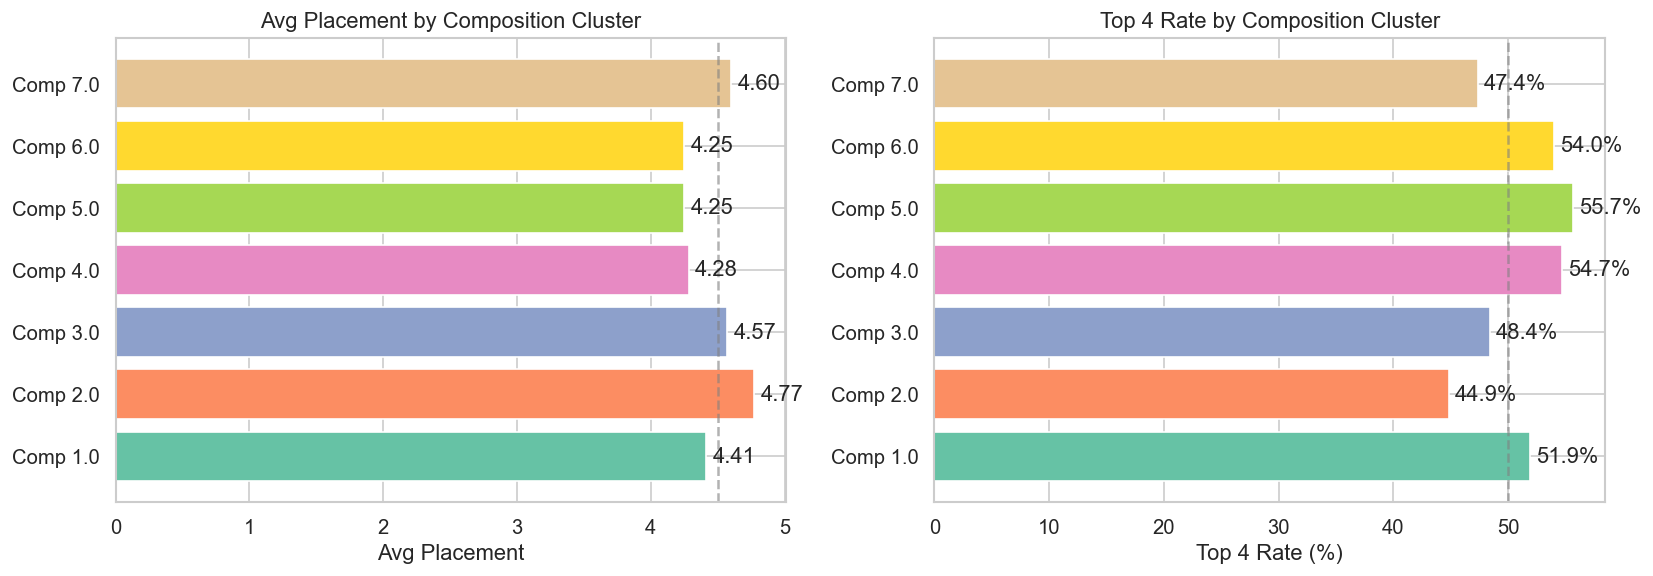

In [11]:
# Average placement per cluster
boards_with_placement = boards.merge(participants[['match_id', 'puuid', 'placement']], on=['match_id', 'puuid'])

cluster_perf = boards_with_placement.groupby('cluster').agg(
    avg_placement=('placement', 'mean'),
    count=('placement', 'size'),
    top4_rate=('placement', lambda x: (x <= 4).mean() * 100)
).reset_index()
cluster_perf['label'] = cluster_perf.apply(
    lambda r: f"Comp {r['cluster']+1}", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Avg placement
colors = sns.color_palette('Set2', n_clusters)
ax1.barh(cluster_perf['label'], cluster_perf['avg_placement'], color=colors)
ax1.axvline(4.5, color='gray', linestyle='--', alpha=0.6)
ax1.set_xlabel('Avg Placement')
ax1.set_title('Avg Placement by Composition Cluster')
for i, row in cluster_perf.iterrows():
    ax1.text(row['avg_placement'] + 0.05, i, f"{row['avg_placement']:.2f}", va='center')

# Top 4 rate
ax2.barh(cluster_perf['label'], cluster_perf['top4_rate'], color=colors)
ax2.axvline(50, color='gray', linestyle='--', alpha=0.6)
ax2.set_xlabel('Top 4 Rate (%)')
ax2.set_title('Top 4 Rate by Composition Cluster')
for i, row in cluster_perf.iterrows():
    ax2.text(row['top4_rate'] + 0.5, i, f"{row['top4_rate']:.1f}%", va='center')

plt.tight_layout()
plt.show()

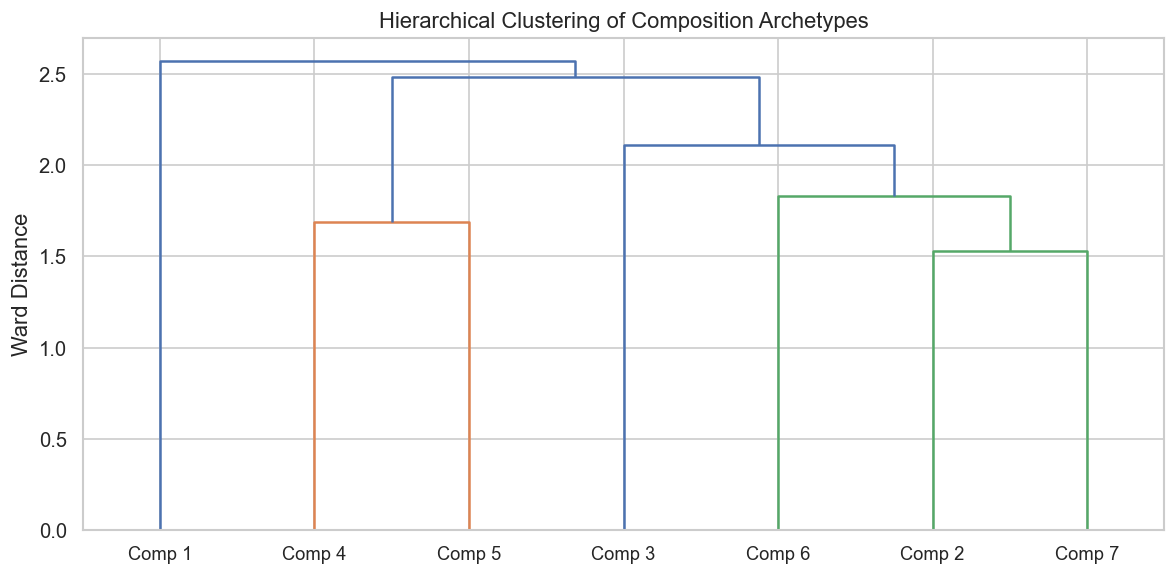

In [12]:
# Hierarchical clustering dendrogram on cluster centers
Z = linkage(km.cluster_centers_, method='ward')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=[f'Comp {i+1}' for i in range(n_clusters)], ax=ax,
           leaf_font_size=11, color_threshold=2.0)
ax.set_title('Hierarchical Clustering of Composition Archetypes')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.show()

In [13]:
# Print the defining champions for each comp
print('=== Composition Archetypes (Top champions per cluster) ===\n')
for i in range(n_clusters):
    top_champs = centers.iloc[i].nlargest(8)
    top_champs = top_champs[top_champs > 0.15]  # filter low-signal champions
    champ_str = ', '.join([f'{name} ({val:.0%})' for name, val in top_champs.items()])
    perf = cluster_perf[cluster_perf['cluster'] == i].iloc[0]
    print(f"Comp {i+1} (n={perf['count']:.0f}, avg={perf['avg_placement']:.2f}, top4={perf['top4_rate']:.1f}%):")
    print(f"  {champ_str}\n")

=== Composition Archetypes (Top champions per cluster) ===

Comp 1 (n=724, avg=4.41, top4=51.9%):
  Wukong (97%), Yunara (97%), Sett (97%), Shen (91%), Swain (76%), Kindred (73%), Shyvana (61%), Taric (43%)

Comp 2 (n=1947, avg=4.77, top4=44.9%):
  Swain (59%), Vi (54%), Neeko (48%), Shyvana (38%), Taric (29%), Seraphine (24%), Azir (20%), Lucian (19%)

Comp 3 (n=1623, avg=4.57, top4=48.4%):
  Loris (96%), Seraphine (82%), Braum (78%), Orianna (49%), Vi (48%), Azir (47%), THex (43%), Ornn (41%)

Comp 4 (n=685, avg=4.28, top4=54.7%):
  RiftHerald (99%), ChoGath (90%), Swain (71%), Wukong (60%), Volibear (57%), Shyvana (45%), Lucian (24%), BelVeth (23%)

Comp 5 (n=1169, avg=4.25, top4=55.7%):
  Ambessa (98%), Swain (92%), BelVeth (72%), Fiddlesticks (63%), Shyvana (62%), Sion (52%), RiftHerald (40%), Lucian (36%)

Comp 6 (n=881, avg=4.25, top4=54.0%):
  Nautilus (75%), MissFortune (75%), Lucian (70%), Shyvana (62%), Kindred (61%), Wukong (49%), Ornn (31%), Swain (27%)

Comp 7 (n=948, avg

**Key Finding:** KMeans successfully identifies distinct meta compositions. Each cluster is characterized by a core group of champions that frequently appear together (sharing traits). The performance comparison reveals which comps are strongest (lowest avg placement, highest top-4 rate) in the current meta. The dendrogram shows how similar some comp archetypes are to each other — closely linked comps share several flex units.